In [1]:
!pip install -q qiskit
!pip install -q qiskit_aer
!pip install -q matplotlib
!pip install -q qiskit-ibm-runtime
!pip install -q "qiskit[visualization]" matplotlib pylatexenc

In [2]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator

In [3]:
# Import AerSimulator from Qiskit Aer
# Used to simulate quantum circuits locally (without real hardware)
from qiskit_aer import AerSimulator

# Create a simulator instance using the statevector method
# method='statevector' tells the simulator to compute the full quantum state
# Allows us to retrieve amplitudes and visualise states on the Bloch sphere
sim = AerSimulator(method='statevector')


In [4]:
# Import plot_bloch_multivector from Qiskit's visualization module
# Used to display a quantum state on the Bloch sphere
# Works with statevector simulation to show superposition and phase geometrically
from qiskit.visualization import plot_bloch_multivector


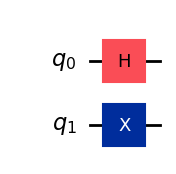

In [5]:
# Create a quantum circuit with 2 qubits (both start in |0⟩)
qc = QuantumCircuit(2)

# Apply Hadamard gate to qubit 0
# Transforms |0⟩ → (|0⟩ + |1⟩)/√2, creating superposition on qubit 0
qc.h(0)

# Apply X gate to qubit 1
# Flips |0⟩ → |1⟩ on the second qubit
qc.x(1)

# Draw the circuit using Matplotlib style
qc.draw('mpl')


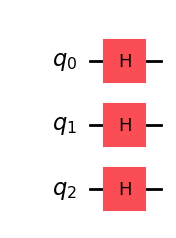

In [6]:
# Create a quantum circuit with 3 qubits (initial state is |000⟩)
qc = QuantumCircuit(3)

# Apply Hadamard gate to each qubit
# The loop runs for i = 0, 1, 2
# Each qc.h(i) puts qubit i into superposition
for i in range(3):
    qc.h(i)

# Draw the circuit using Matplotlib style
qc.draw('mpl')

#Each qubit is now in an equal superposition of |0⟩ and |1⟩. The overall state becomes a superposition of all 8 possible three-qubit states (|000⟩ to |111⟩) with equal probability.


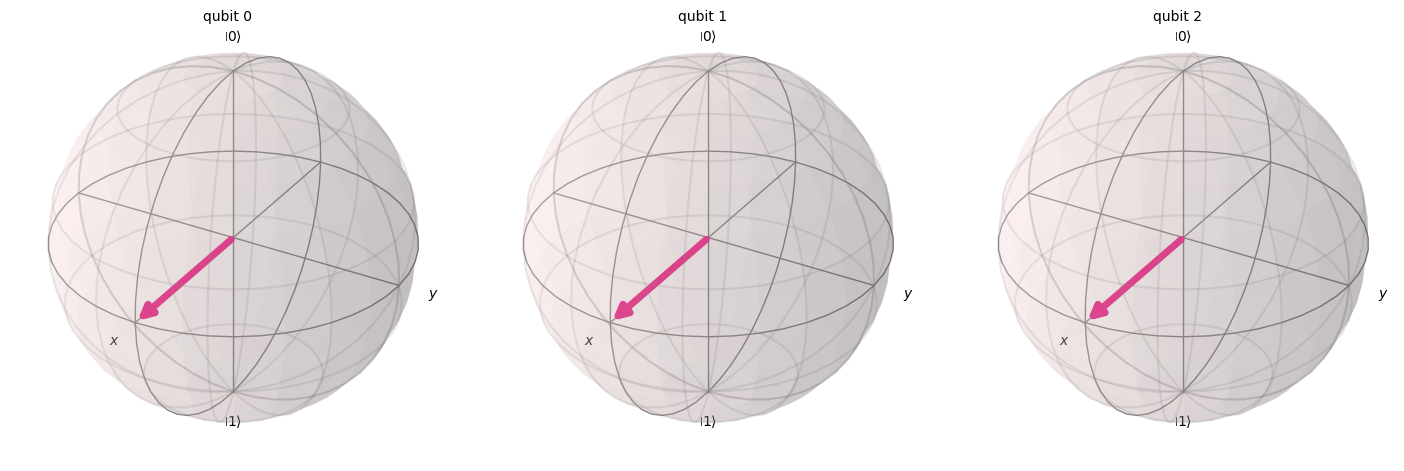

In [7]:
# Save the statevector so the simulator stores the full 3-qubit quantum state
# Required to retrieve the exact amplitudes
qc.save_statevector()

# Run the circuit using the default AerSimulator
# .result() retrieves the execution result
# .get_statevector() extracts the final quantum statevector
state = AerSimulator().run(qc).result().get_statevector()

# Plot the Bloch sphere representation
# For multiple qubits, a separate Bloch sphere is shown for each qubit
plot_bloch_multivector(state)

#Each Bloch sphere now shows a qubit on the equator, meaning each qubit is in equal superposition.
#Since we applied H to all three qubits independently, they are not entangled — just independently in superposition.


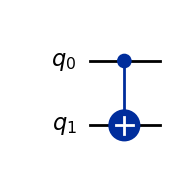

In [ ]:
# Create a quantum circuit with 2 qubits (initial state is |00⟩)
qc = QuantumCircuit(2)

# Apply a CNOT (Controlled-X) gate
# Control qubit = 0, Target qubit = 1
# If qubit 0 is |1⟩, then qubit 1 will be flipped
qc.cx(0, 1)
#([0, 1, 2], [1, 2, 0])
# Draw the circuit using Matplotlib style
qc.draw("mpl")

#Since both qubits start in |00⟩ and the control qubit is |0⟩, nothing changes. The CNOT only flips the target qubit if the control qubit is in state |1⟩.


**CNOT Action on Basis States**

In [9]:
# Create a simulator instance that supports running circuits with measurement
sim = AerSimulator()

# Define a function to prepare a 2-qubit input state, apply CNOT, and return measurement counts
def run(input_state):

    # Create a circuit with 2 qubits and 2 classical bits
    qc = QuantumCircuit(2, 2)

    # Prepare the input state by flipping qubits based on the input bitstring
    # If the first bit is '1', apply X to qubit 0
    if input_state[0] == '1':
        qc.x(0)

    # If the second bit is '1', apply X to qubit 1
    if input_state[1] == '1':
        qc.x(1)

    # Apply CNOT gate (control=0, target=1)
    qc.cx(0, 1)

    # Measure both qubits and store results in the two classical bits
    qc.measure([0, 1], [0, 1])

    # Run the circuit 1024 times (shots) and collect the results
    result = sim.run(qc, shots=1024).result()

    # Return the measurement outcome frequencies
    return result.get_counts()

# Test the CNOT gate for all possible 2-qubit input states
#for s in ["00", "01", "10", "11"]:
    #print(f"Input: |{s}⟩  →  Output:", run(s))

for s in ["00", "01", "10", "11"]:
    counts = run(s)

    # Reverse the printed bitstring so it matches q0 q1 order
    fixed_counts = {bit[::-1]: v for bit, v in counts.items()}

    print(f"Input: |{s}⟩  →  Output:", fixed_counts)




Input: |00⟩  →  Output: {'00': 1024}
Input: |01⟩  →  Output: {'01': 1024}
Input: |10⟩  →  Output: {'11': 1024}
Input: |11⟩  →  Output: {'10': 1024}


**Entanglement**

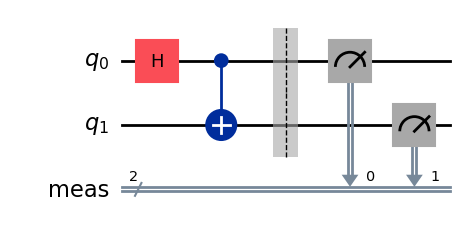

In [10]:
# Create a quantum circuit with 2 qubits (initial state is |00⟩)
qc = QuantumCircuit(2)

# Apply Hadamard gate to qubit 0
# Creates superposition: |0⟩ → (|0⟩ + |1⟩)/√2
qc.h(0)

# Apply CNOT gate (control=0, target=1)
# Entangles the two qubits
qc.cx(0, 1)

# Measure all qubits and store results in classical bits
qc.measure_all()

# Draw the circuit using Matplotlib style
qc.draw("mpl")

#The Hadamard puts the first qubit into superposition, and the CNOT entangles it with the second qubit.
#The resulting state is a Bell state, meaning measurements will give either 00 or 11 with equal probability, never 01 or 10.

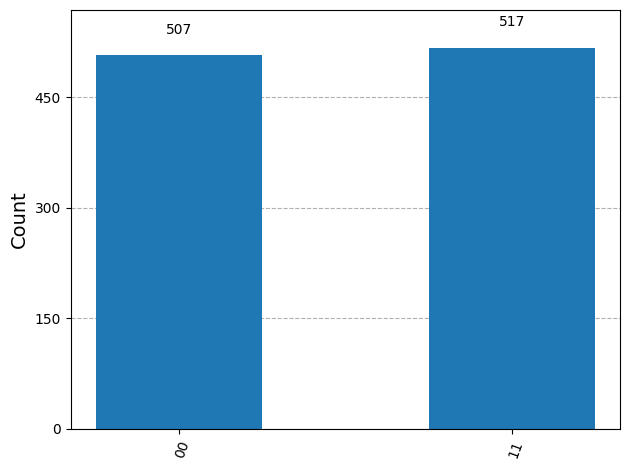

In [11]:
# Import plot_histogram to visualise measurement counts
from qiskit.visualization import plot_histogram

# Execute the circuit 1024 times (shots)
# .run(qc) runs the quantum circuit
# .result() retrieves the execution result
result = sim.run(qc, shots=1024).result()

# Plot the measurement results as a histogram
# .get_counts() returns the frequency of each output bitstring
plot_histogram(result.get_counts())

#You should see only 00 and 11, each appearing roughly 50% of the time.
#This confirms that the two qubits are entangled — measuring one instantly determines the state of the other


**Parameterised Quantum Circuit**

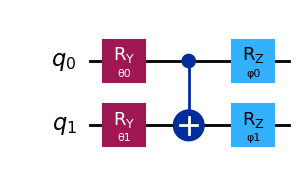

In [12]:
# Import Parameter class to create symbolic parameters
# Used in parameterized quantum circuits (PQC) for trainable angles
from qiskit.circuit import Parameter

# Define symbolic parameters
# These act like variables whose values can be assigned later
θ0 = Parameter('θ0')
θ1 = Parameter('θ1')
φ0 = Parameter('φ0')
φ1 = Parameter('φ1')

# Create a two-qubit parameterized quantum circuit
pqc = QuantumCircuit(2)

# Apply parameterized Ry rotations
# These can represent data encoding or trainable weights
pqc.ry(θ0, 0)
pqc.ry(θ1, 1)

# Apply an entangling CNOT gate
# Creates correlation between the two qubits
pqc.cx(0, 1)

# Apply additional parameterized Rz rotations
# These are typically trainable parameters in variational circuits
pqc.rz(φ0, 0)
pqc.rz(φ1, 1)

# Draw the parameterized circuit
pqc.draw("mpl")

#This is a parameterized quantum circuit (PQC) where the rotation angles are symbolic variables instead of fixed numbers.
#These parameters can later be trained or optimized, which is how quantum machine learning and variational algorithms like VQE work.


**Assign Parameters**

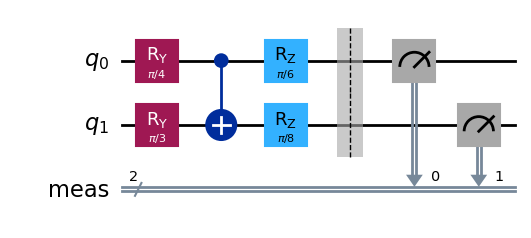

In [13]:
# Import NumPy to access numerical constants like π
import numpy as np

# Define numerical values for the symbolic parameters
# These values will replace θ0, θ1, φ0, φ1 in the circuit
param_values = {
    θ0: np.pi/4,
    θ1: np.pi/3,
    φ0: np.pi/6,
    φ1: np.pi/8,
}

# Assign the numerical values to the parameterized circuit
# inplace=False creates a new circuit with parameters substituted
pqc_meas = pqc.assign_parameters(param_values, inplace=False)

# Add measurement to all qubits
# Converts the circuit into a measurable experiment
pqc_meas.measure_all()

# Draw the updated circuit with concrete parameter values
pqc_meas.draw("mpl")

#Here we replace the symbolic parameters with real numerical values, turning the abstract PQC into a concrete executable circuit.
#This is exactly how variational algorithms work, parameters are updated repeatedly during optimisation.



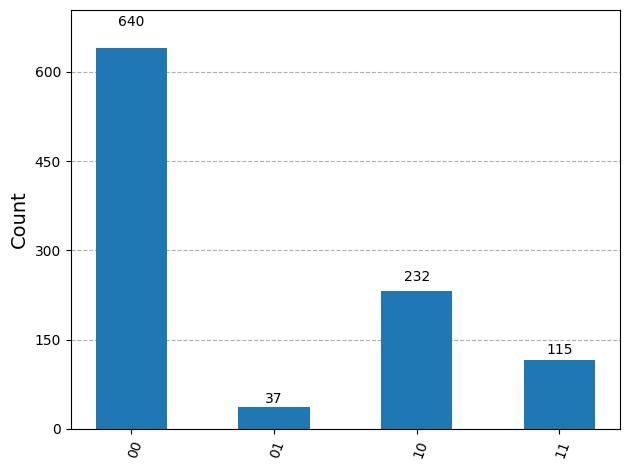

In [14]:
# Create a simulator instance to run the parameterized circuit
sim = AerSimulator()

# Execute the measured parameterized circuit 1024 times (shots)
# .run() runs the circuit
# .result() retrieves the execution result
result = sim.run(pqc_meas, shots=1024).result()

# Plot the measurement results as a histogram
# .get_counts() returns the frequency of each output bitstring
plot_histogram(result.get_counts())

#Now the parameterized circuit is executed with concrete angle values, and the histogram shows the probability distribution over the four possible two-qubit outcomes (00, 01, 10, 11).
#In a variational algorithm, these probabilities would depend on the parameters and change during optimisation.

**Circuit Depth**

In [15]:
# Print the circuit depth
# Depth represents the number of sequential layers of gates
# Higher depth usually means more noise on real hardware
print("Circuit depth:", pqc.depth())

# Print the number of qubits in the circuit
# Shows how many quantum wires the circuit uses
print("Number of qubits:", pqc.num_qubits)

# Print the count of each type of gate in the circuit
# Useful for analysing circuit complexity
print("Gate counts:\n", pqc.count_ops())

#Circuit depth tells us how many layers of operations are applied sequentially, which impacts noise on real devices.
#Gate counts help us understand the circuit’s complexity and resource usage.


Circuit depth: 3
Number of qubits: 2
Gate counts:
 OrderedDict({'ry': 2, 'rz': 2, 'cx': 1})


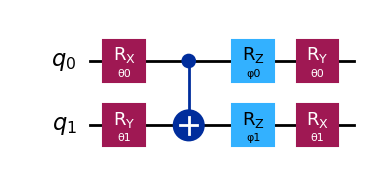

In [16]:
# Create a two-qubit parameterized quantum circuit
pqc = QuantumCircuit(2)

# Apply parameterized Rx rotation to qubit 0
# Rotation around the X-axis by angle θ0
pqc.rx(θ0, 0)
# Apply parameterized Ry rotation to qubit 1
# Rotation around the Y-axis by angle θ1
pqc.ry(θ1, 1)
# Apply entangling CNOT gate (control=0, target=1)
# Creates correlation between the two qubits

pqc.cx(0, 1)
# Apply parameterized Rz rotations to both qubits
# Adds phase rotations by angles φ0 and φ1

pqc.rz(φ0, 0)
pqc.rz(φ1, 1)

# Add additional parameterized rotations
# These increase circuit expressiveness and depth
pqc.ry(θ0, 0)
pqc.rx(θ1, 1)

# Draw the circuit using Matplotlib style
pqc.draw("mpl")


In [17]:
# Print the circuit depth
# Depth is the number of sequential layers of gates
# More depth usually means more noise on real quantum hardware
print("Circuit depth:", pqc.depth())

# Print the number of qubits used in the circuit
# Indicates the size of the quantum system
print("Number of qubits:", pqc.num_qubits)

# Print the count of each type of gate in the circuit
# Helps analyse circuit complexity and resource usage
print("Gate counts:\n", pqc.count_ops())


Circuit depth: 4
Number of qubits: 2
Gate counts:
 OrderedDict({'rx': 2, 'ry': 2, 'rz': 2, 'cx': 1})


**Transpilation**

=== BEFORE TRANSPILATION ===


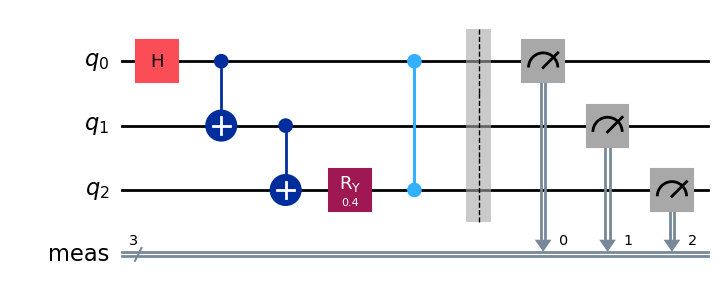

In [18]:
# Import QuantumCircuit to build quantum circuits
from qiskit import QuantumCircuit

# Import generate_preset_pass_manager to create a transpilation workflow
# Used to optimise circuits for specific hardware backends
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Import AerSimulator to simulate circuits locally
from qiskit_aer import AerSimulator

# Build a sample 3-qubit circuit (initial state |000⟩)
qc = QuantumCircuit(3)

# Apply Hadamard to qubit 0 (creates superposition)
qc.h(0)

# Apply CNOT gates to create a chain of entanglement
qc.cx(0, 1)
qc.cx(1, 2)

# Apply a rotation around Y-axis to qubit 2
qc.ry(0.4, 2)

# Apply controlled-Z between qubit 2 and 0
qc.cz(2, 0)

# Measure all qubits
qc.measure_all()

# Print header text
print("=== BEFORE TRANSPILATION ===")

# Display the circuit diagram before optimisation
display(qc.draw("mpl"))


#This is our logical circuit, written using ideal gates without worrying about hardware constraints.
#Before running on real hardware, we must transpile it so the circuit matches the device’s allowed gate set and connectivity.

=== AFTER TRANSPILATION ===


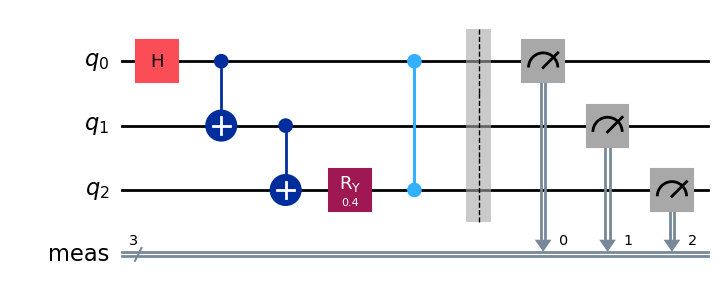

In [19]:
# Choose a backend (here we use AerSimulator as a target device)
# The target defines which gates and connectivity are allowed
sim = AerSimulator()

# Generate a preset pass manager with optimisation level 3
# optimisation_level=3 applies aggressive circuit optimisation
# target=sim.target ensures the circuit is adapted to this backend
pm = generate_preset_pass_manager(optimization_level=3, target=sim.target)

# Run the transpilation process on the original circuit
# This rewrites the circuit to match backend constraints
qc_opt = pm.run(qc)

# Print header text
print("=== AFTER TRANSPILATION ===")

# Display the optimised (transpiled) circuit
display(qc_opt.draw("mpl"))

#After transpilation, the circuit may look different because it has been rewritten to match the backend’s allowed gate set and connectivity.
#Optimisation level 3 tries to reduce circuit depth and gate count, making it more efficient and less noisy on real hardware.


**Let's Build a Simple Circuit**

=== BEFORE Transpilation ===


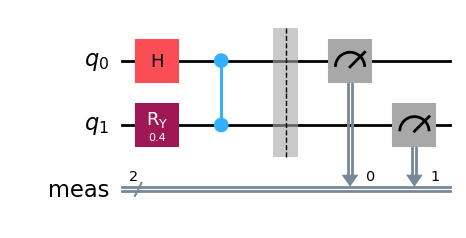

In [20]:
# Import QuantumCircuit to create quantum circuits
from qiskit import QuantumCircuit

# Create a quantum circuit with 2 qubits (initial state |00⟩)
qc = QuantumCircuit(2)

# Apply Hadamard gate to qubit 0 (creates superposition)
qc.h(0)

# Apply a rotation around Y-axis to qubit 1
# Rotates qubit 1 by 0.4 radians
qc.ry(0.4, 1)

# Apply controlled-Z gate between qubit 0 and qubit 1
# Adds a conditional phase if both qubits are |1⟩
qc.cz(0, 1)

# Measure all qubits
qc.measure_all()

# Print header text
print("=== BEFORE Transpilation ===")

# Display the circuit diagram before optimisation
display(qc.draw("mpl"))

#This is the logical version of our two-qubit circuit using ideal gates like CZ.
#Before running on real hardware, transpilation will rewrite this circuit into the backend’s supported gate set and connectivity.

**Transpile with a simple gate set**

=== AFTER Transpilation ===


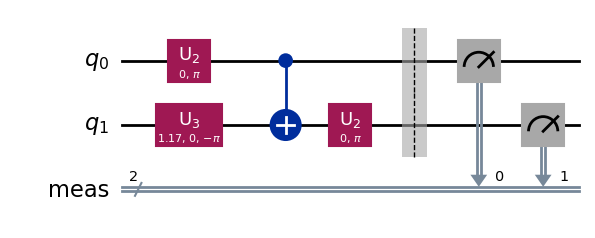

In [21]:
# Import the transpile function
# Used to convert a circuit into a form compatible with a chosen gate set or backend
from qiskit import transpile

# Transpile the circuit
# basis_gates specifies the allowed gate set (u1, u2, u3, cx)
# optimization_level=1 applies light optimisation
qc_t = transpile(qc, basis_gates=['u1', 'u2', 'u3', 'cx'], optimization_level=1)

# Print header text
print("=== AFTER Transpilation ===")

# Display the transpiled circuit
display(qc_t.draw("mpl"))

#After transpilation, gates like H, RY, and CZ may be rewritten using only the allowed basis gates (u1, u2, u3, cx).
#This is necessary because real quantum hardware supports only a limited set of native gates.

**Binary-Classification Demo (Optional)**

In [22]:
# Import NumPy for numerical operations
import numpy as np

# Import Iris dataset from scikit-learn
# We will use it for a simple quantum classification example
from sklearn.datasets import load_iris

# Import StandardScaler to normalize features
# Important for stable training in machine learning
from sklearn.preprocessing import StandardScaler

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import QuantumCircuit to build quantum circuits
from qiskit import QuantumCircuit

# Import AerSimulator to simulate circuits locally
from qiskit_aer import AerSimulator

# Import SparsePauliOp to define observables (for expectation values)
from qiskit.quantum_info import SparsePauliOp


# --- Load Iris dataset (using 2 features only) ---
# We select sepal length and petal length
iris = load_iris()
X_full = iris.data[:, [0, 2]]   # column 0 = sepal length, column 2 = petal length
y_full = iris.target           # class labels


# Keep only Setosa (class 0) and Versicolor (class 1)
# This turns it into a binary classification problem
mask = y_full < 2
X = X_full[mask]
y = y_full[mask]


# Standardize features (mean=0, variance=1)
# Helps prevent one feature dominating the model
scaler = StandardScaler()
X = scaler.fit_transform(X)


# Split data into training (80%) and testing (20%)
# shuffle=True mixes the data randomly
# random_state=0 ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=0
)

# Print dataset sizes
print("Train size:", X_train.shape, "Test size:", X_test.shape)

#We are preparing a simple binary classification problem using two Iris features.
#After standardizing the data and splitting into training and testing sets, we are ready to encode these features into a quantum circuit.


Train size: (80, 2) Test size: (20, 2)


In [23]:
# Define number of qubits for the quantum model (2 qubits for 2 input features)
n_qubits = 2

# Create a 2-qubit simulator using the statevector method (gives the full quantum state)
sim_qml = AerSimulator(method="statevector")

# Define the observable Z ⊗ I (measure Z on qubit 0, identity on qubit 1)
# This lets us compute the expectation value ⟨Z⟩ of the first qubit
Z0 = SparsePauliOp.from_list([("ZI", 1.0)])

# Define the parameterized quantum circuit (PQC) for Iris inputs
def pqc_iris(x, params):

    # Create a quantum circuit with n_qubits qubits
    qc = QuantumCircuit(n_qubits)

    # ----- Data encoding layer -----
    # Encode feature x[0] into qubit 0 using an Ry rotation
    qc.ry(float(x[0]), 0)

    # Encode feature x[1] into qubit 1 using an Ry rotation
    qc.ry(float(x[1]), 1)

    # ----- Entanglement layer -----
    # Apply CNOT to entangle qubit 0 (control) with qubit 1 (target)
    qc.cx(0, 1)

    # ----- Variational / trainable layer -----
    # Trainable rotations on qubit 0
    qc.ry(params[0], 0)
    qc.rz(params[1], 0)

    # Trainable rotations on qubit 1
    qc.ry(params[2], 1)
    qc.rz(params[3], 1)

    # Return the circuit (no measurement here because we use expectation values)
    return qc


# Define the model forward pass: returns probability for class 1
def model_output(x, params):
    """
    Forward pass of the quantum model.
    Returns P(class = 1) using expectation <Z0>.
    """

    # Build the PQC for this input x and parameter set params
    qc = pqc_iris(x, params)

    # Save the statevector so the simulator stores the full quantum state
    qc.save_statevector()

    # Run the circuit and retrieve the final statevector
    result = sim_qml.run(qc).result()
    state = result.get_statevector()

    # Compute expectation value of Z on qubit 0 (value is in [-1, 1])
    exp_z0 = np.real(state.expectation_value(Z0))

    # Convert expectation value to probability in [0, 1]
    # Mapping: exp_z0 = +1 → p1 = 0, exp_z0 = -1 → p1 = 1
    p1 = (1.0 - exp_z0) / 2.0

    # Return probability of class 1
    return p1


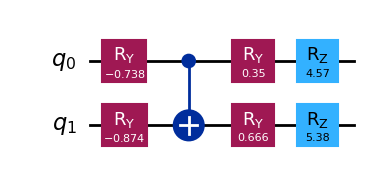

In [24]:
# Import Matplotlib for plotting (if needed for additional visualisation)
import matplotlib.pyplot as plt

# Generate random parameter values in the range [0, 2π]
# These act as initial random weights for the variational layer
example_params = np.random.uniform(0, 2*np.pi, 4)

# Select one training example from the dataset
# This is a 2-dimensional feature vector
example_x = X_train[0]

# Build the parameterized quantum circuit for this input and parameter set
qc_example = pqc_iris(example_x, example_params)

# Draw the circuit using Matplotlib style
qc_example.draw("mpl")

#Here we randomly initialise the trainable parameters and encode one training sample into the quantum circuit.
#This shows how classical data and trainable weights combine inside the parameterized quantum circuit before optimisation.

In [25]:
# Import the minimize function from SciPy
# Used for classical optimisation of the quantum model parameters
from scipy.optimize import minimize

# Define the loss function
# Computes mean squared error between predicted probabilities and true labels
def loss(params, X_data, y_data):
    """
    Mean squared error between predicted P(class=1) and labels {0,1}.
    """

    # Compute predictions for each input sample
    preds = np.array([model_output(x, params) for x in X_data])

    # Return average squared difference between predictions and labels
    return np.mean((preds - y_data) ** 2)


# Initialize parameters randomly in the range [0, 2π)
# Setting seed ensures reproducibility
np.random.seed(0)
theta_init = np.random.uniform(0, 2*np.pi, 4)

# Compute and print initial training loss
print("Initial loss:", loss(theta_init, X_train, y_train))

# Perform classical optimisation using Nelder-Mead method
# This method does not require gradients
res = minimize(
    fun=lambda th: loss(th, X_train, y_train),  # Objective function
    x0=theta_init,                             # Initial parameters
    method="Nelder-Mead",                      # Gradient-free optimisation
    options={"maxiter": 120, "disp": True}     # Maximum iterations and display progress
)

# Extract optimized parameters
theta_opt = res.x

# Print optimized parameters
print("Optimized parameters:", theta_opt)

# Compute training loss after optimisation
print("Training loss after optimization:", loss(theta_opt, X_train, y_train))

# Here, a classical optimizer adjusts the quantum circuit parameters to minimize the loss function.
#This hybrid loop, quantum forward pass plus classical optimization, is the core idea behind variational quantum algorithms and quantum machine learning.

Initial loss: 0.600129344068222
Optimization terminated successfully.
         Current function value: 0.015547
         Iterations: 73
         Function evaluations: 136
Optimized parameters: [4.09424701 5.5634904  1.64371242 3.66818897]
Training loss after optimization: 0.015547065323891962


In [26]:
# Define prediction function
# Converts model probability output into a binary class label (0 or 1)
def predict(x, theta):

    # Get probability of class 1 from the quantum model
    p1 = model_output(x, theta)

    # Apply threshold at 0.5 to decide class
    return 1 if p1 >= 0.5 else 0


# Define accuracy function
# Computes classification accuracy over a dataset
def accuracy(X_data, y_data, theta):

    # Generate predictions for all samples
    preds = np.array([predict(x, theta) for x in X_data])

    # Compute fraction of correct predictions
    return np.mean(preds == y_data)


# Compute training accuracy
train_acc = accuracy(X_train, y_train, theta_opt)

# Compute test accuracy
test_acc = accuracy(X_test, y_test, theta_opt)

# Print results
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Test accuracy:     {test_acc * 100:.2f}%")

#After optimization, we convert the quantum model’s probability output into class labels using a 0.5 threshold.
#The accuracy tells us how well the trained quantum circuit generalizes on both training and unseen test data, completing the full hybrid quantum-classical workflow.

Training accuracy: 100.00%
Test accuracy:     100.00%


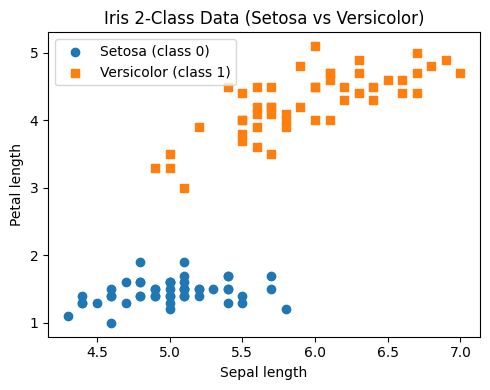

In [27]:
# Import Matplotlib for plotting
import matplotlib.pyplot as plt

# Use original (unscaled) feature values for visualization
# X_full, y_full, and mask were defined earlier
X_vis = X_full[mask]
y_vis = y_full[mask]

# Separate the two classes
# Class 0 = Setosa
setosa = X_vis[y_vis == 0]

# Class 1 = Versicolor
versicolor = X_vis[y_vis == 1]

# Create a figure with specified size
plt.figure(figsize=(5, 4))

# Plot Setosa samples
plt.scatter(setosa[:, 0], setosa[:, 1],
            label="Setosa (class 0)", marker="o")

# Plot Versicolor samples
plt.scatter(versicolor[:, 0], versicolor[:, 1],
            label="Versicolor (class 1)", marker="s")

# Label axes
plt.xlabel("Sepal length")
plt.ylabel("Petal length")

# Add plot title
plt.title("Iris 2-Class Data (Setosa vs Versicolor)")

# Add legend
plt.legend()

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

#This plot shows the two Iris classes in the original feature space before scaling.
#You can see that Setosa and Versicolor are reasonably separable, which makes this a good example for testing our quantum classifier.